<a href="https://colab.research.google.com/github/VigneshPambala/DV-Project/blob/main/Resnet_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib seaborn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install tensorflow

In [5]:
# prompt: code for unzipping Data.zip which is present in the runtime

import zipfile

# Specify the path to your zip file
zip_file_path = "Data.zip"  # Replace with the actual filename if different

# Create a ZipFile object
try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Extract all the contents of the zip file to the current directory
        zip_ref.extractall()
        print(f"Successfully extracted {zip_file_path}")
except FileNotFoundError:
    print(f"Error: {zip_file_path} not found.")
except zipfile.BadZipFile:
    print(f"Error: {zip_file_path} is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully extracted Data.zip


In [6]:
# importing libraries
import numpy as np
import pandas as pd
import os
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger

In [8]:
# dataset path
dataset = "/content/Data"

In [9]:
# printing list Tumours we are classifying
import os

dataset = "Data"  # replace with your actual path

classes = [file for file in os.listdir(dataset) if os.path.isdir(os.path.join(dataset, file))]

print("The following classes of Tumours are to be classified")
print(classes)

The following classes of Tumours are to be classified
['pituitary_tumor', 'glioma_tumor', 'normal', 'meningioma_tumor']


In [10]:
# function to load and preprocess and data labeling
def loader(directory):
    dataset = []
    labels = []
    labelMapping = {
        'normal': 0,
        'pituitary_tumor': 1,
        'meningioma_tumor': 2,
        'glioma_tumor': 3,
    }
    tempCount = {}
    for file in os.listdir(directory):
        if file == ".DS_Store":
            continue
        path = os.path.join(directory, file)
        for im in os.listdir(path):
            img = cv2.imread(os.path.join(path, im))
            image = cv2.resize(img, (256, 256))
            label = path.split("/")[-1]
            if label not in tempCount:
                tempCount[label] = 1
            else:
                tempCount[label] += 1
            if tempCount[label] <= 300:
                dataset.append(image)
                labels.append(labelMapping[os.path.basename(label)])

    return np.array(dataset), np.array(labels)

In [12]:
# loading trianing datasets
x, y = loader(dataset)

In [13]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
# displaying the shape of the dataset
print((xtrain.shape, ytrain.shape, xtest.shape, ytest.shape))

((960, 256, 256, 3), (960,), (240, 256, 256, 3), (240,))


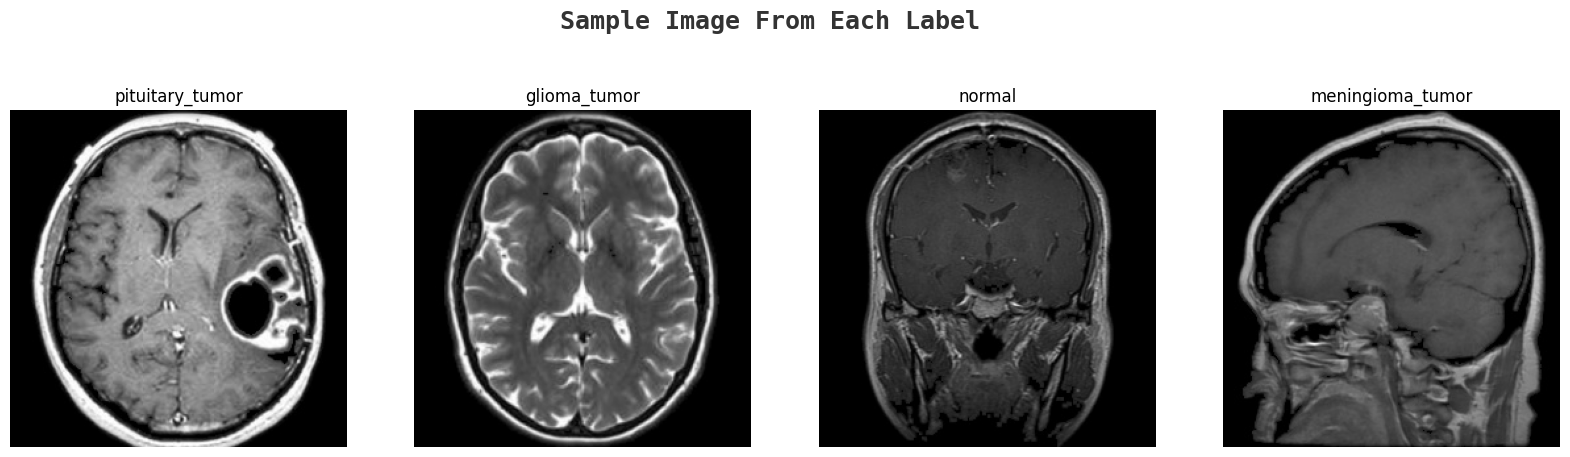

In [15]:
# displaying training images
k = 0
fig, ax = plt.subplots(1, 4, figsize=(20, 20))
labelMapping = {
    0: 'normal',
    1: 'pituitary_tumor',
    2: 'meningioma_tumor',
    3: 'glioma_tumor'
}
fig.text(s='Sample Image From Each Label',
         size=18,
         fontweight='bold',
         fontname='monospace',
         y=0.62,
         x=0.4,
         alpha=0.8)
for i in classes:
    j = 0
    while True:
        if labelMapping[j] == i:
            ax[k].imshow(xtrain[j])
            ax[k].set_title(labelMapping[j])
            ax[k].axis('off')
            k += 1
            break
        j += 1

In [16]:
# converting array into categorical
label_encoder = LabelEncoder()

encoded_labels = label_encoder.fit_transform(ytrain)
ytrainLabels = to_categorical(encoded_labels, num_classes=len(classes))

ytest_encoded_labels = label_encoder.fit_transform(ytest)
ytestLabels = to_categorical(ytest_encoded_labels, num_classes=len(classes))

In [17]:
train = tf.data.Dataset.from_tensor_slices((xtrain, ytrainLabels)).batch(32).prefetch(1)
test = tf.data.Dataset.from_tensor_slices((xtest, ytestLabels)).batch(32).prefetch(1)

In [18]:
# displaying the categorical label
##print((ytrainLabels[:5]))
##print((ytestLabels[:5]))

In [19]:
# image preprocessing
datagen = ImageDataGenerator(horizontal_flip=True,
                             vertical_flip=True,
                             rotation_range=20,
                             zoom_range=0.2,
                             width_shift_range=0.2,
                             height_shift_range=0.2,
                             shear_range=0.1,
                             fill_mode="nearest")

In [20]:
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

# Train generator
train_generator = datagen.flow(xtrain, ytrainLabels, batch_size=32, subset='training')
validation_generator = datagen.flow(xtrain, ytrainLabels, batch_size=32, subset='validation')

In [21]:
# creating ResNet50 model
# residual connections, which allow the network to learn a set of residual functions that map the input to the desired output
#These layers are responsible for extracting features from the input image, such as edges, textures, and shapes
def Resnet50():
    input = Input(shape=(150, 150, 3))
    output = ZeroPadding2D(padding=3, name='padding_conv1')(input)
    output = Conv2D(64, (7, 7), strides=(2, 2), use_bias=False, name='conv1')(output)
    output = BatchNormalization(axis=3, epsilon=1e-5, name='bn_conv1')(output)
    output = Activation('relu', name='conv1_relu')(output)
    output = MaxPooling2D((3, 3), strides=(2, 2), padding='same', name='pool1')(output)

    output = conv_block(output, 3, [64, 64, 256], stage=2, block='a', strides=(1, 1))
    output = identity_block(output, 3, [64, 64, 256], stage=2, block='b')
    output = identity_block(output, 3, [64, 64, 256], stage=2, block='c')

    output = conv_block(output, 3, [128, 128, 512], stage=3, block='a')
    output = identity_block(output, 3, [128, 128, 512], stage=3, block='b')
    output = identity_block(output, 3, [128, 128, 512], stage=3, block='c')
    output = identity_block(output, 3, [128, 128, 512], stage=3, block='d')

    output = conv_block(output, 3, [256, 256, 1024], stage=4, block='a')
    output = identity_block(output, 3, [256, 256, 1024], stage=4, block='b')
    output = identity_block(output, 3, [256, 256, 1024], stage=4, block='c')
    output = identity_block(output, 3, [256, 256, 1024], stage=4, block='d')
    output = identity_block(output, 3, [256, 256, 1024], stage=4, block='e')
    output = identity_block(output, 3, [256, 256, 1024], stage=4, block='f')

    output = conv_block(output, 3, [512, 512, 2048], stage=5, block='a')
    output = identity_block(output, 3, [512, 512, 2048], stage=5, block='b')
    output = identity_block(output, 3, [512, 512, 2048], stage=5, block='c')
    output = GlobalAveragePooling2D(name='pool5')(output)
    output = Dense(len(classes), activation='softmax', name='fc1000')(output)
    model = Model(inputs=input, outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model


def identity_block(input, kernel_size, filters, stage, block):
    filters1, filters2, filters3 = filters
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    output = Conv2D(filters1, (1, 1), kernel_initializer='he_normal', name=conv_name_base + '2a')(input)
    output = BatchNormalization(axis=3, name=bn_name_base + '2a')(output)
    output = Activation('relu')(output)
    output = Conv2D(filters2, kernel_size, padding='same', kernel_initializer='he_normal',
                                 name=conv_name_base + '2b')(output)
    output = BatchNormalization(axis=3, name=bn_name_base + '2b')(output)
    output = Activation('relu')(output)
    output = Conv2D(filters3, (1, 1), kernel_initializer='he_normal', name=conv_name_base + '2c')(output)
    output = BatchNormalization(axis=3, name=bn_name_base + '2c')(output)
    output = add([output, input])
    output = Activation('relu')(output)

    return output


def conv_block(input, kernel_size, filters, stage, block, strides=(2, 2)):

    filters1, filters2, filters3 = filters
    conv_name_base = 'res' + str(stage) + block + '_branch'
    bn_name_base = 'bn' + str(stage) + block + '_branch'

    output = Conv2D(filters1, (1, 1), strides=strides, kernel_initializer='he_normal', name=conv_name_base + '2a')(input)
    output = BatchNormalization(axis=3, name=bn_name_base + '2a')(output)
    output = Activation('relu')(output)
    output = Conv2D(filters2, kernel_size, padding='same', kernel_initializer='he_normal', name=conv_name_base + '2b')(output)
    output = BatchNormalization(axis=3, name=bn_name_base + '2b')(output)
    output = Activation('relu')(output)
    output = Conv2D(filters3, (1, 1), kernel_initializer='he_normal', name=conv_name_base + '2c')(output)
    output = BatchNormalization(axis=3, name=bn_name_base + '2c')(output)
    shortcut = Conv2D(filters3, (1, 1), strides=strides, kernel_initializer='he_normal', name=conv_name_base + '1')(input)
    shortcut = BatchNormalization(axis=3, name=bn_name_base + '1')(shortcut)
    output = add([output, shortcut])
    output = Activation('relu')(output)

    return output

model = Resnet50()


In [22]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


conv_block = ResNet50(include_top=False, weights="imagenet")
x= GlobalAveragePooling2D()(conv_block.output)
x= Dropout(0.5)(x)
output = Dense(4, activation="softmax",kernel_regularizer=l2(0.001))(x)
model = Model(inputs=conv_block.input, outputs=output)
learning_rate = 0.0001
c_optimizer = Adam(learning_rate=learning_rate)

model.compile(
    loss="categorical_crossentropy",
    optimizer=c_optimizer,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [23]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

In [24]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [25]:
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [27]:
# training the model
his = model.fit(train, validation_data=test, batch_size=256, epochs=50,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)]
               )

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 377ms/step - accuracy: 1.0000 - loss: 0.0084 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8667 - val_loss: 0.4423 - val_precision: 0.8777 - val_recall: 0.8375
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 401ms/step - accuracy: 1.0000 - loss: 0.0084 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8708 - val_loss: 0.4365 - val_precision: 0.8821 - val_recall: 0.8417
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step - accuracy: 1.0000 - loss: 0.0084 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8708 - val_loss: 0.4351 - val_precision: 0.8745 - val_recall: 0.8417
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 394ms/step - accuracy: 1.0000 - loss: 0.0083 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8708 - val_loss: 0.4271 - val_precision: 0.8718 - val_recall: 0.8500
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 393ms/step - accuracy: 1.0000 - loss: 0.0082 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8792 - val_los

In [28]:
# Saving the model
print("Saving network...")
model.save("/content/ResNet.keras")
print("Saved model to disk")

Saving network...
Saved model to disk


In [29]:
def plot_metrics(history):
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))

    # Training
    axes[0][0].plot(range(1, len(history.history["loss"]) + 1), history.history["loss"])
    axes[0][1].plot(range(1, len(history.history["accuracy"]) + 1), history.history["accuracy"])
    axes[1][0].plot(range(1, len(history.history["precision"]) + 1), history.history["precision"])
    axes[1][1].plot(range(1, len(history.history["recall"]) + 1), history.history["recall"])

    # Validation
    axes[0][0].plot(range(1, len(history.history["val_loss"]) + 1), history.history["val_loss"])
    axes[0][1].plot(range(1, len(history.history["val_accuracy"]) + 1), history.history["val_accuracy"])
    axes[1][0].plot(range(1, len(history.history["val_precision"]) + 1), history.history["val_precision"])
    axes[1][1].plot(range(1, len(history.history["val_recall"]) + 1), history.history["val_recall"])

    axes[0][0].set_title("Loss Comparison", fontdict={'fontsize': 20})
    axes[0][0].set_xlabel("Epoch")
    axes[0][0].set_ylabel("Loss")

    axes[0][1].set_title("Accuracy Comparison", fontdict={'fontsize': 20})
    axes[0][1].set_xlabel("Epoch")
    axes[0][1].set_ylabel("Accuracy")

    axes[1][0].set_title("Precision Comparison", fontdict={'fontsize': 20})
    axes[1][0].set_xlabel("Epoch")
    axes[1][0].set_ylabel("Precision")

    axes[1][1].set_title("Recall Comparison", fontdict={'fontsize': 20})
    axes[1][1].set_xlabel("Epoch")
    axes[1][1].set_ylabel("Recall")

    plt.tight_layout()
    plt.show()


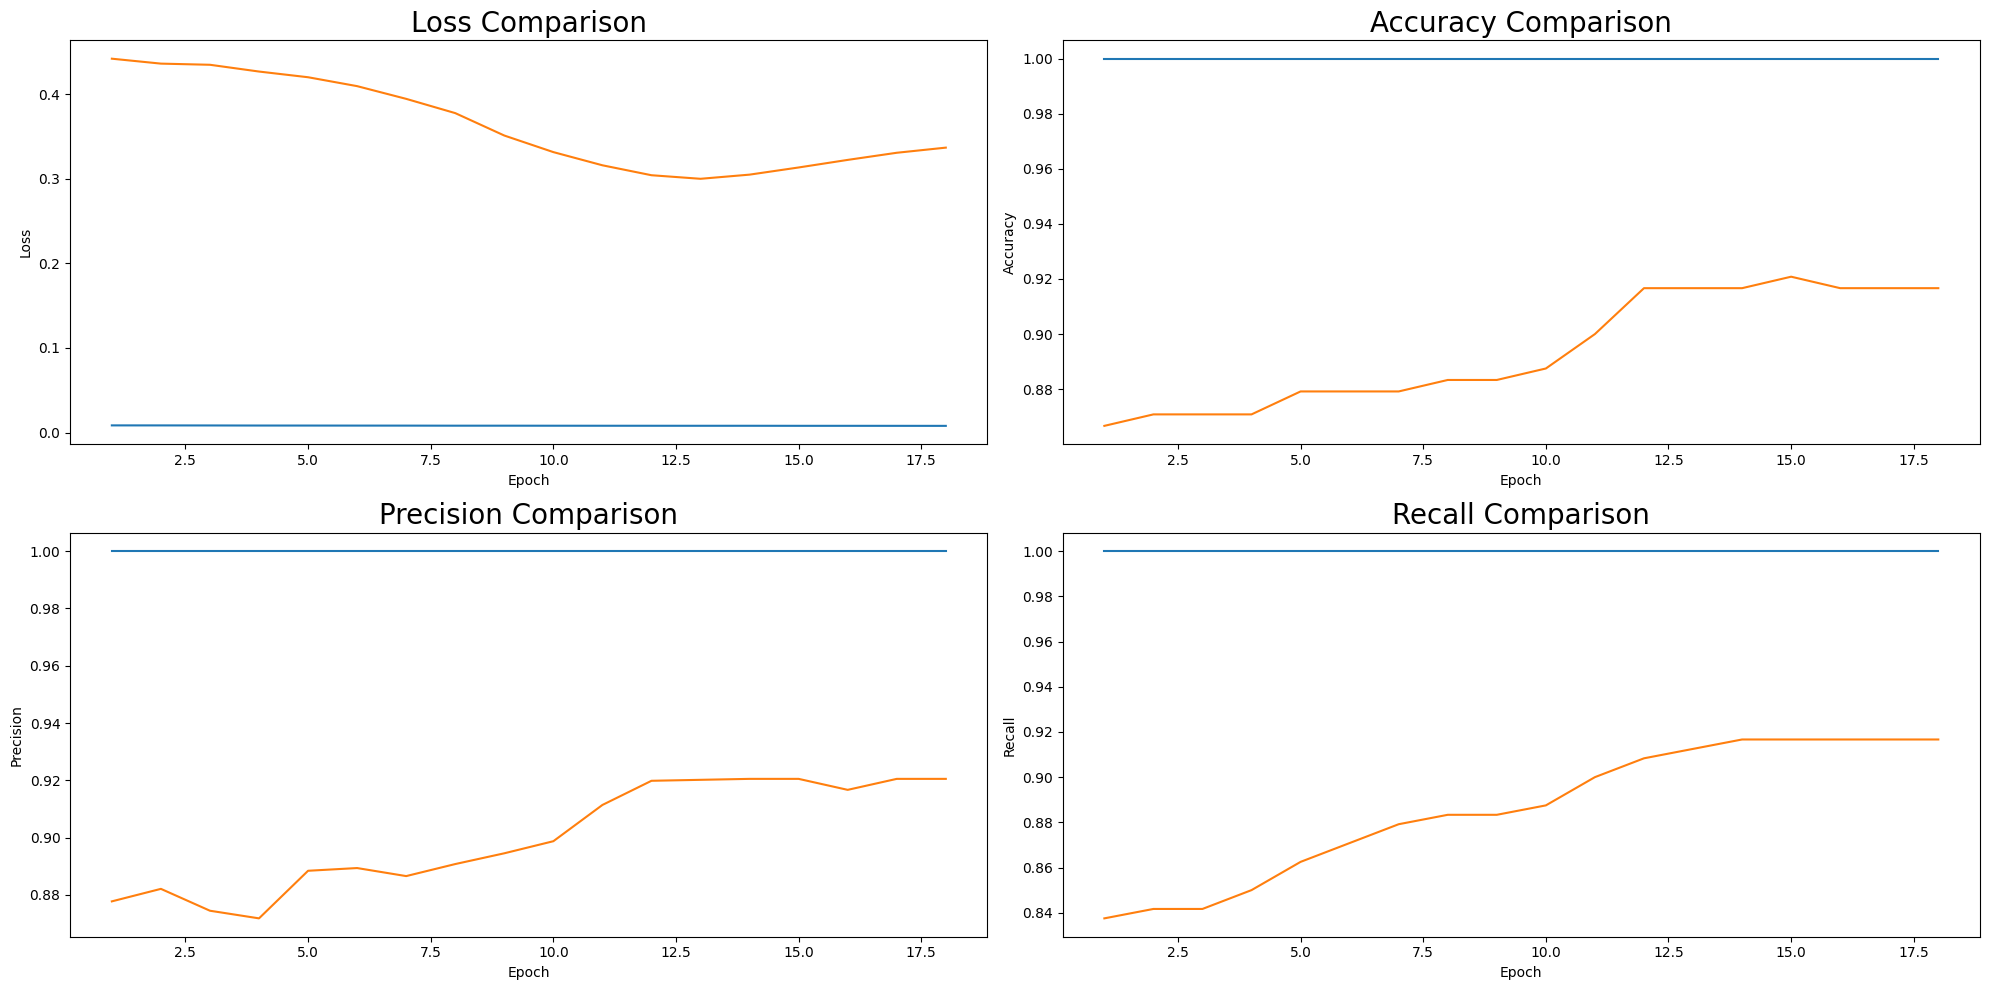

In [30]:
plot_metrics(his)

In [31]:
y_pred = model.predict(xtest)
pred = np.argmax(y_pred, axis=1)
ground = np.argmax(ytestLabels, axis=1)
##print((classification_report(ground, pred)))

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 609ms/step


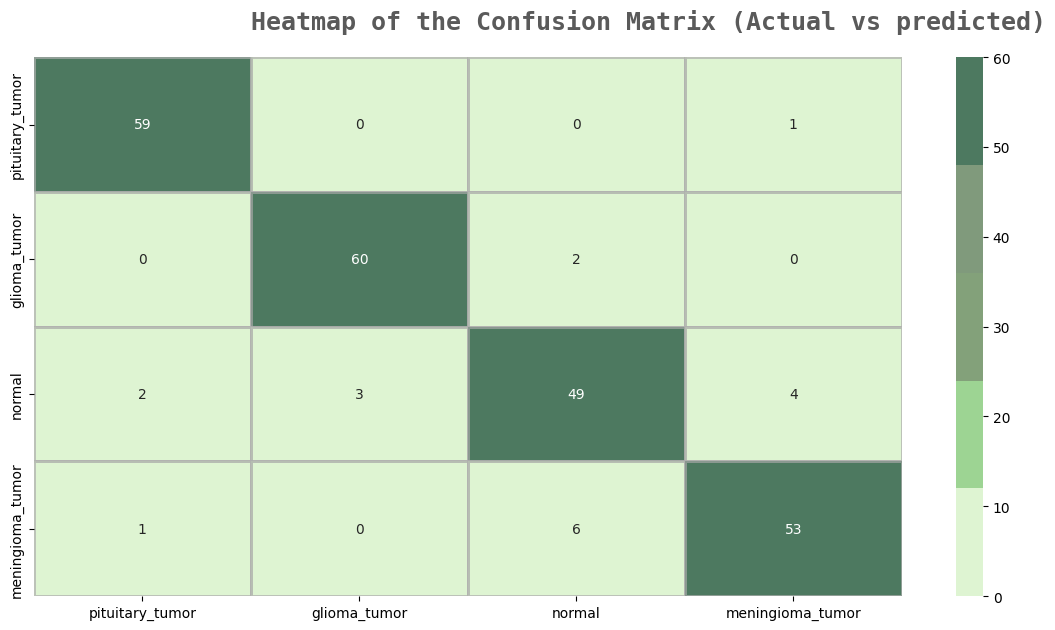

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
colors_dark = ["#1F1F1F", "#313131", '#636363', '#AEAEAE', '#DADADA']
colors_red = ["#331313", "#582626", '#9E1717', '#D35151', '#E9B4B4']
colors_green = ['#01411C','#4B6F44','#4F7942','#74C365','#D0F0C0']

sns.heatmap(confusion_matrix(ground, pred),
            ax=ax,
            xticklabels=classes,
            yticklabels=classes,
            annot=True,
            cmap=colors_green[::-1],
            alpha=0.7,
            linewidths=2,
            linecolor=colors_dark[3])
fig.text(s='Heatmap of the Confusion Matrix (Actual vs predicted)',
         size=18,
         fontweight='bold',
         fontname='monospace',
         color=colors_dark[1],
         y=0.92,
         x=0.28,
         alpha=0.8)

plt.show()

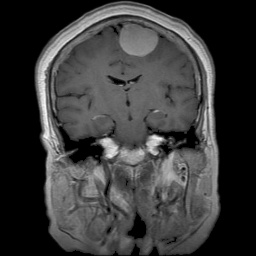

In [33]:
# real time testing
load_img(dataset+"/meningioma_tumor/M_111.jpg",target_size=(256,256))

In [34]:
img = cv2.imread(dataset+"/meningioma_tumor/M_111.jpg")
image = cv2.resize(img, (256, 256))
prediction_image = np.array(image)
prediction_image = np.expand_dims(image, axis=0)

In [35]:
labelMapping = {
    0: 'normal',
    1: 'pituitary_tumor',
    2: 'meningioma_tumor',
    3: 'glioma_tumor'
}

prediction = model.predict(prediction_image)
value = np.argmax(prediction)
move_name = labelMapping[value]
print(("Prediction is {} with the confidence of {:.3f}.".format(move_name, max(prediction[0]))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction is meningioma_tumor with the confidence of 1.000.
